📥 Téléchargement SPY (01/01/2000 - 31/12/2024)...
✅ Période: 2000-02-01 à 2024-12-30 | 6268 observations

🧠 Entraînement du LSTM...
Epoch 1/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 1.3819e-05 - val_loss: 2.5546e-06 - learning_rate: 0.0010
Epoch 2/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 3.3435e-06 - val_loss: 2.0904e-06 - learning_rate: 0.0010
Epoch 3/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 2.5392e-06 - val_loss: 1.0747e-06 - learning_rate: 0.0010
Epoch 4/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 2.0058e-06 - val_loss: 9.3286e-07 - learning_rate: 0.0010
Epoch 5/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 1.8062e-06 - val_loss: 8.1397e-07 - learning_rate: 5.0000e-04
Epoch 6/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - loss: 1.5720e-06 - val_loss: 7.8325e-07 - learning_rate: 5.0000e-04
Epoch 7/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 1.5614e-06 - val_loss: 7.6163e-07 - learning_rate: 5.0000e-04
Epoch 8/30
125/125 ━━━━

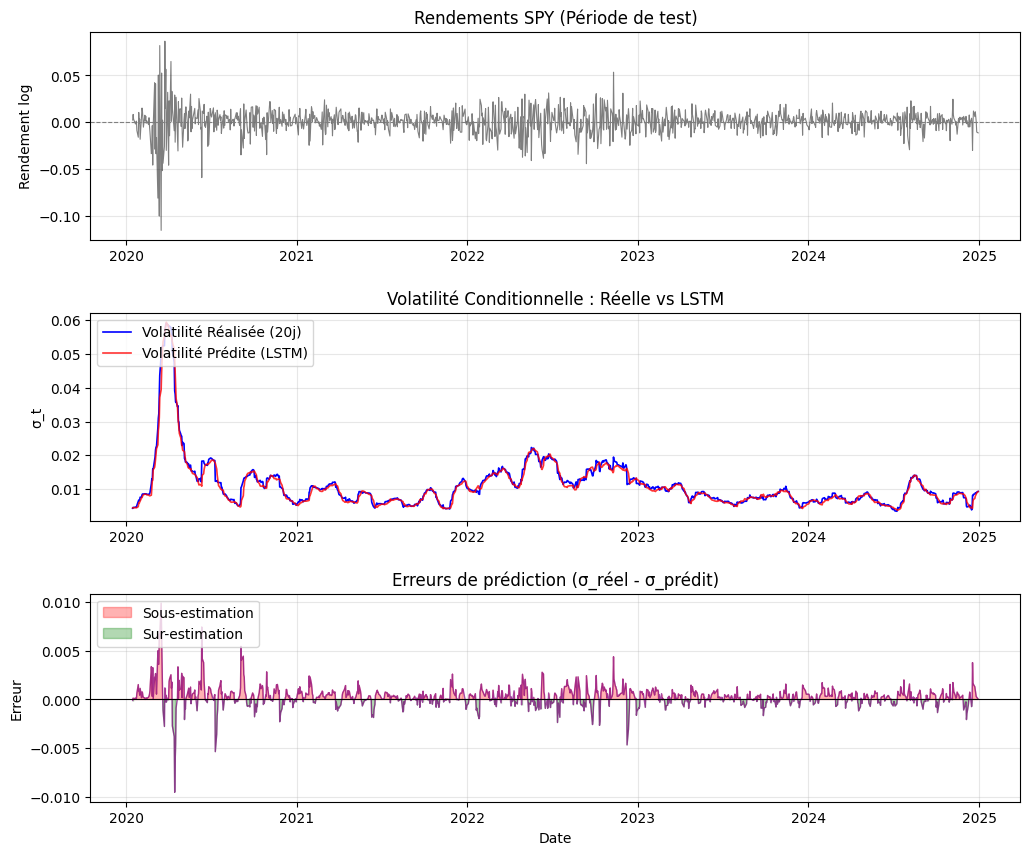


💾 Résultats LSTM sauvegardés dans /content/lstm_volatility_results.pkl


In [ ]:
# =============================================================================
# lstm_volatility.py : Modélisation de la volatilité conditionnelle (LSTM)
# Remplace le workflow GARCH par une approche LSTM | Google Colab Ready
# =============================================================================
# 1. Dépendances
!pip install -q yfinance tensorflow pandas numpy scikit-learn matplotlib

import numpy as np
import pandas as pd
import yfinance as yf
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import pickle
import warnings
warnings.filterwarnings('ignore')

# Reproductibilité
np.random.seed(42)
tf.random.set_seed(42)

# =============================================================================
# 1. Chargement & Préparation des données
# =============================================================================
print("📥 Téléchargement SPY (01/01/2000 - 31/12/2024)...")
raw = yf.download('SPY', start='2000-01-01', end='2024-12-31', progress=False)

# 🔧 Nettoyage robuste des colonnes yfinance
if isinstance(raw.columns, pd.MultiIndex):
    raw.columns = [' '.join(col).strip() for col in raw.columns]
price_col = next((c for c in raw.columns if 'Close' in c), None)
if price_col is None:
    raise ValueError("⚠️ Colonne de prix introuvable dans les données")

df = raw[[price_col]].copy().rename(columns={price_col: 'price'})
df.index = pd.to_datetime(df.index)
if df.index.tz is not None:
    df.index = df.index.tz_localize(None)
df = df.loc[(df.index >= '2000-01-01') & (df.index <= '2024-12-31')]

df['returns'] = np.log(df['price'] / df['price'].shift(1))
df = df.dropna()
df['vol_20'] = df['returns'].rolling(window=20).std()
df = df.dropna()

print(f"✅ Période: {df.index[0].strftime('%Y-%m-%d')} à {df.index[-1].strftime('%Y-%m-%d')} | {len(df)} observations")

# =============================================================================
# 2. Préparation des séquences LSTM
# =============================================================================
lookback = 30
features = ['returns', 'vol_20']
X, y = [], []
for i in range(lookback, len(df)):
    X.append(df[features].iloc[i-lookback:i].values)
    y.append(df['vol_20'].iloc[i])
X, y = np.array(X), np.array(y)

split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# =============================================================================
# 3. Modèle LSTM & Entraînement (remplace la grille GARCH)
# =============================================================================
print("\n🧠 Entraînement du LSTM...")
model = Sequential([
    LSTM(64, return_sequences=False, input_shape=(lookback, 2)),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3), loss='mse')

# Callbacks pour éviter le surapprentissage & remplacer la sélection par BIC
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)
]

history = model.fit(
    X_train, y_train,
    epochs=30, batch_size=32, validation_split=0.2,
    callbacks=callbacks, verbose=1
)

# =============================================================================
# 4. Prédictions & Évaluation (remplace la table AIC/BIC)
# =============================================================================
print("\n📊 Évaluation du modèle...")
y_pred = model.predict(X_test, verbose=0).flatten()

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
corr = np.corrcoef(y_test, y_pred)[0, 1]

eval_df = pd.DataFrame({
    'Métrique': ['MSE', 'RMSE', 'MAE', 'Corrélation'],
    'Valeur': [mse, rmse, mae, corr]
})
print(eval_df)

# Alignement temporel pour les diagnostics
test_start_idx = lookback + split
test_end_idx = test_start_idx + len(y_pred)
test_dates = df.index[test_start_idx:test_end_idx]

# =============================================================================
# 5. Diagnostics & Graphiques (équivalent aux plots R)
# =============================================================================
print("\n📈 Génération des diagnostics...")
fig, axes = plt.subplots(3, 1, figsize=(12, 10), gridspec_kw={'hspace': 0.35})

# Rendements
axes[0].plot(test_dates, df['returns'].iloc[test_start_idx:test_end_idx],
             color='black', alpha=0.5, linewidth=0.8)
axes[0].axhline(0, color='gray', linestyle='--', linewidth=0.8)
axes[0].set_title('Rendements SPY (Période de test)')
axes[0].set_ylabel('Rendement log')
axes[0].grid(True, alpha=0.3)

# Volatilité prédite vs réalisée
axes[1].plot(test_dates, y_test, label='Volatilité Réalisée (20j)', color='blue', linewidth=1.2)
axes[1].plot(test_dates, y_pred, label='Volatilité Prédite (LSTM)', color='red', linewidth=1.2, alpha=0.8)
axes[1].set_title('Volatilité Conditionnelle : Réelle vs LSTM')
axes[1].set_ylabel('σ_t')
axes[1].legend(loc='upper left')
axes[1].grid(True, alpha=0.3)

# Erreurs de prédiction
errors = y_test - y_pred
axes[2].plot(test_dates, errors, color='purple', alpha=0.7, linewidth=1)
axes[2].axhline(0, color='black', linestyle='-', linewidth=0.8)
axes[2].fill_between(test_dates, errors, 0, where=errors>0, color='red', alpha=0.3, label='Sous-estimation')
axes[2].fill_between(test_dates, errors, 0, where=errors<0, color='green', alpha=0.3, label='Sur-estimation')
axes[2].set_title('Erreurs de prédiction (σ_réel - σ_prédit)')
axes[2].set_ylabel('Erreur')
axes[2].set_xlabel('Date')
axes[2].legend(loc='upper left')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# =============================================================================
# 6. Sauvegarde complète (équivalent au saveRDS)
# =============================================================================
output_path = '/content/lstm_volatility_results.pkl'
results = {
    'model': model,
    'training_history': history.history,
    'test_predictions': y_pred,
    'test_actuals': y_test,
    'test_dates': test_dates,
    'evaluation_metrics': eval_df.to_dict('records'),
    'hyperparams': {'lookback': lookback, 'train_split': 0.8, 'units': [64, 32], 'dropout': 0.2},
    'data_info': {
        'ticker': 'SPY',
        'start_date': df.index[0].strftime('%Y-%m-%d'),
        'end_date': df.index[-1].strftime('%Y-%m-%d'),
        'n_train': len(X_train),
        'n_test': len(X_test),
        'date_run': pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')
    }
}

with open(output_path, 'wb') as f:
    pickle.dump(results, f)

print(f"\n💾 Résultats LSTM sauvegardés dans {output_path}")

📥 Chargement des données SPY & modèle LSTM...
✅ Période test: 2020-02-20 à 2024-12-30 | 1224 jours

🔄 Calcul des VaR alternatives (rolling, window=2000, α=0.05)...
🔗 Alignement des séries temporelles...
📏 Lignes valides après filtrage : 1224

📊 Backtesting VaR...
    Méthode  Violations  Taux_viol   p_UC   p_CC
       LSTM          71     0.0580 0.2096 0.4120
 Historique          80     0.0654 0.0183 0.0013
    Normale          73     0.0596 0.1326 0.0047
RiskMetrics          73     0.0596 0.1326 0.3066

📉 Calcul du Quantile Loss...
    Méthode  Moyenne_perte
RiskMetrics       0.001474
       LSTM       0.001481
    Normale       0.001737
 Historique       0.001743

📈 Génération du graphique comparatif...


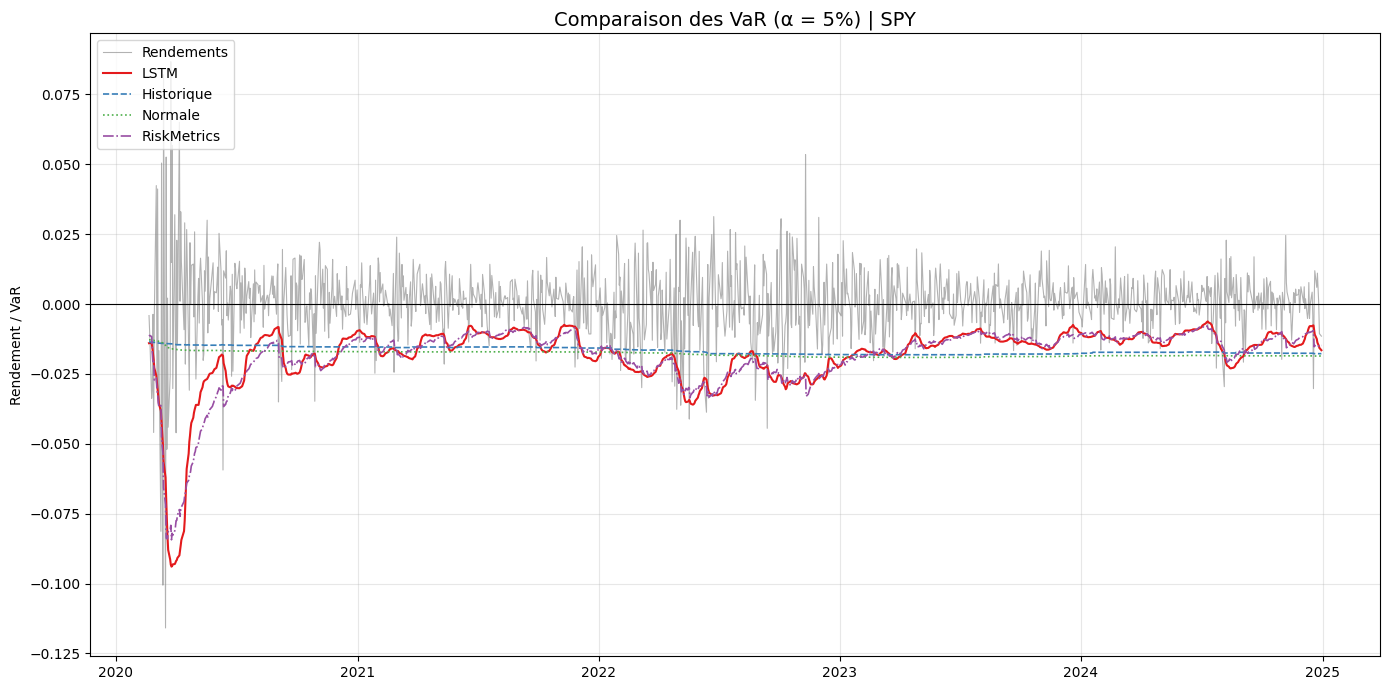


💾 Résultats sauvegardés dans : /content/VaR_LSTM_Results.pkl


In [45]:
# ==============================================================================
# Value-at-Risk_LSTM.py : Estimation + Backtesting (LSTM vs Alternatives)
# Remplace le workflow eGARCH par LSTM | Google Colab Ready
# ==============================================================================
!pip install -q yfinance tensorflow pandas numpy scipy matplotlib

import numpy as np
import pandas as pd
import yfinance as yf
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from scipy.stats import norm, chi2
import matplotlib.pyplot as plt
import pickle
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
tf.random.set_seed(42)

# ==============================================================================
# 1. Chargement des données & Modèle LSTM
# ==============================================================================
print("📥 Chargement des données SPY & modèle LSTM...")
raw = yf.download('SPY', start='2000-01-01', end='2024-12-31', progress=False)
if isinstance(raw.columns, pd.MultiIndex):
    raw.columns = [' '.join(c).strip() for c in raw.columns]
price_col = next((c for c in raw.columns if 'Close' in c), 'Close')
df = raw[[price_col]].copy().rename(columns={price_col: 'price'})
df.index = pd.to_datetime(df.index)
if df.index.tz is not None: df.index = df.index.tz_localize(None)
df = df.loc[(df.index >= '2000-01-01') & (df.index <= '2024-12-31')]

df['returns'] = np.log(df['price'] / df['price'].shift(1))
df = df.dropna()
df['vol_20'] = df['returns'].rolling(window=20).std()
df = df.dropna()

# Préparer séquences & entraîner
lookback, split = 30, int(0.8 * len(df))
X, y = [], []
for i in range(lookback, len(df)):
    X.append(df[['returns','vol_20']].iloc[i-lookback:i].values)
    y.append(df['vol_20'].iloc[i])
X, y = np.array(X), np.array(y)
X_train, X_test, y_train, y_test = X[:split], X[split:], y[:split], y[split:]

model = Sequential([LSTM(64, return_sequences=False, input_shape=(lookback, 2)), Dropout(0.2), Dense(1)])
model.compile(optimizer='adam', loss='mse')
model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.2, verbose=0)

# ✅ CORRECTION : pred_col -> pred_vol
pred_vol = model.predict(X_test, verbose=0).flatten()
test_start_idx = lookback + split
test_dates = df.index[test_start_idx : test_start_idx + len(pred_vol)]
returns_test = df['returns'].iloc[test_start_idx : test_start_idx + len(pred_vol)]

print(f"✅ Période test: {test_dates[0].strftime('%Y-%m-%d')} à {test_dates[-1].strftime('%Y-%m-%d')} | {len(test_dates)} jours")

# ==============================================================================
# 2. Calcul des VaR Alternatives (Rolling)
# ==============================================================================
alpha_level = 0.05
window_size = 2000
print(f"\n🔄 Calcul des VaR alternatives (rolling, window={window_size}, α={alpha_level})...")

def compute_rolling_var(r, window, alpha):
    n = len(r)
    VaR_hist = np.full(n, np.nan)
    VaR_norm = np.full(n, np.nan)
    VaR_rm = np.full(n, np.nan)
    sigma_rm_sq = r.iloc[:window].var()
    lam = 0.94

    for i in range(window, n):
        win = r.iloc[i-window:i]
        VaR_hist[i] = np.quantile(win, alpha)
        mu, sig = win.mean(), win.std()
        VaR_norm[i] = mu + sig * norm.ppf(alpha)

        if i > window:
            sigma_rm_sq = lam * sigma_rm_sq + (1 - lam) * r.iloc[i-1]**2
        VaR_rm[i] = np.sqrt(sigma_rm_sq) * norm.ppf(alpha)
    return VaR_hist, VaR_norm, VaR_rm

r_full = df['returns']
v_hist, v_norm, v_rm = compute_rolling_var(r_full, window_size, alpha_level)

# ==============================================================================
# 3. Alignement & Construction du DataFrame Comparatif
# ==============================================================================
print("🔗 Alignement des séries temporelles...")
df_comp = pd.DataFrame({
    'date': test_dates,
    'realized': returns_test.values,
    'VaR_LSTM': norm.ppf(alpha_level, scale=pred_vol),
    'VaR_Hist': v_hist[test_start_idx : test_start_idx + len(pred_vol)],
    'VaR_Norm': v_norm[test_start_idx : test_start_idx + len(pred_vol)],
    'VaR_RM':   v_rm[test_start_idx : test_start_idx + len(pred_vol)]
})

# Nettoyage strict (NA, Inf, NaN)
df_clean = df_comp.replace([np.inf, -np.inf], np.nan).dropna()
print(f"📏 Lignes valides après filtrage : {len(df_clean)}")

# ==============================================================================
# 4. Backtesting (Kupiec UC & Christoffersen CC) - VERSION CORRIGÉE
# ==============================================================================
print("\n📊 Backtesting VaR...")

def backtest_method(name, realized, VaR, alpha):
    realized = np.asarray(realized)
    VaR = np.asarray(VaR)
    n = len(realized)
    I = (realized < VaR).astype(int)
    x = I.sum()
    p_hat = x / n if x > 0 else 1e-9 # Fallback pour éviter log(0)

    # Fonction utilitaire pour calculer x * log(y) de manière sûre (évite les NaN)
    def safe_xlog(x_val, y_val):
        return x_val * np.log(max(y_val, 1e-12)) if x_val > 0 else 0.0

    # --- 1. Test de Kupiec (Unconditional Coverage - UC) ---
    # Forme développée (plus stable que le ratio)
    L0_uc = safe_xlog(n-x, 1-alpha) + safe_xlog(x, alpha)
    L1_uc = safe_xlog(n-x, 1-p_hat) + safe_xlog(x, p_hat)
    LR_uc = -2 * (L0_uc - L1_uc)

    # Protection contre les erreurs d'arrondi flottant (LR ne peut pas être négatif)
    LR_uc = max(LR_uc, 0.0)
    p_uc = 1 - chi2.cdf(LR_uc, df=1)

    # --- 2. Test de Christoffersen (Conditional Coverage - CC) ---
    n00 = np.sum((I[:-1]==0) & (I[1:]==0))
    n01 = np.sum((I[:-1]==0) & (I[1:]==1))
    n10 = np.sum((I[:-1]==1) & (I[1:]==0))
    n11 = np.sum((I[:-1]==1) & (I[1:]==1))

    # Probabilités conditionnelles
    pi1 = n01 / (n00 + n01) if (n00+n01)>0 else p_hat
    pi2 = n11 / (n10 + n11) if (n10+n11)>0 else p_hat
    pi  = (n01 + n11) / n

    # Hypothèse H0 (Indépendance)
    L0_ind = safe_xlog(n00+n10, 1-pi) + safe_xlog(n01+n11, pi)

    # Hypothèse H1 (Markov)
    L1_ind = (safe_xlog(n00, 1-pi1) + safe_xlog(n01, pi1) +
              safe_xlog(n10, 1-pi2) + safe_xlog(n11, pi2))

    LR_ind = -2 * (L0_ind - L1_ind)
    LR_ind = max(LR_ind, 0.0)

    LR_cc = LR_uc + LR_ind
    p_cc = 1 - chi2.cdf(LR_cc, df=2)

    return {
        'Méthode': name,
        'Violations': x,
        'Taux_viol': round(x/n, 4),
        'p_UC': round(p_uc, 4),
        'p_CC': round(p_cc, 4)
    }

back_res = pd.DataFrame([
    backtest_method("LSTM", df_clean['realized'], df_clean['VaR_LSTM'], alpha_level),
    backtest_method("Historique", df_clean['realized'], df_clean['VaR_Hist'], alpha_level),
    backtest_method("Normale", df_clean['realized'], df_clean['VaR_Norm'], alpha_level),
    backtest_method("RiskMetrics", df_clean['realized'], df_clean['VaR_RM'], alpha_level)
])
print(back_res.to_string(index=False))

# ==============================================================================
# 5. Quantile Loss (Fonction de perte)
# ==============================================================================
print("\n📉 Calcul du Quantile Loss...")
alpha = alpha_level
df_clean['Loss_LSTM'] = (df_clean['realized'] - df_clean['VaR_LSTM']) * (alpha - (df_clean['realized'] < df_clean['VaR_LSTM']).astype(int))
df_clean['Loss_Hist'] = (df_clean['realized'] - df_clean['VaR_Hist'])  * (alpha - (df_clean['realized'] < df_clean['VaR_Hist']).astype(int))
df_clean['Loss_Norm'] = (df_clean['realized'] - df_clean['VaR_Norm'])  * (alpha - (df_clean['realized'] < df_clean['VaR_Norm']).astype(int))
df_clean['Loss_RM']   = (df_clean['realized'] - df_clean['VaR_RM'])    * (alpha - (df_clean['realized'] < df_clean['VaR_RM']).astype(int))

loss_summary = pd.DataFrame({
    'Méthode': ['LSTM', 'Historique', 'Normale', 'RiskMetrics'],
    'Moyenne_perte': [df_clean[c].mean() for c in ['Loss_LSTM','Loss_Hist','Loss_Norm','Loss_RM']]
}).sort_values('Moyenne_perte')
print(loss_summary.to_string(index=False))

# ==============================================================================
# 6. Visualisation
# ==============================================================================
print("\n📈 Génération du graphique comparatif...")
plt.figure(figsize=(14, 7))
plt.plot(df_clean['date'], df_clean['realized'], color='gray', alpha=0.6, linewidth=0.8, label='Rendements')
plt.plot(df_clean['date'], df_clean['VaR_LSTM'], color='#E41A1C', linewidth=1.5, label='LSTM')
plt.plot(df_clean['date'], df_clean['VaR_Hist'], color='#377EB8', linewidth=1.2, linestyle='--', label='Historique')
plt.plot(df_clean['date'], df_clean['VaR_Norm'], color='#4DAF4A', linewidth=1.2, linestyle=':', label='Normale')
plt.plot(df_clean['date'], df_clean['VaR_RM'], color='#984EA3', linewidth=1.2, linestyle='-.', label='RiskMetrics')
plt.axhline(0, color='black', linestyle='-', linewidth=0.8)
plt.title(f'Comparaison des VaR (α = {alpha_level*100:.0f}%) | SPY', fontsize=14)
plt.ylabel('Rendement / VaR')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ==============================================================================
# 7. Sauvegarde
# ==============================================================================
save_path = '/content/VaR_LSTM_Results.pkl'
with open(save_path, 'wb') as f:
    pickle.dump({
        'data': df_clean,
        'backtest': back_res,
        'losses': loss_summary,
        'model': model,
        'metadata': {
            'alpha': alpha_level,
            'window_size': window_size,
            'model_used': 'LSTM',
            'date_run': pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S'),
            'ticker': 'SPY'
        }
    }, f)
print(f"\n💾 Résultats sauvegardés dans : {save_path}")